## 1. Introduction & Objectives
This notebook demonstrates how to predict the Remaining Useful Life (RUL) of turbofan engines using the CMAPSS dataset. We encompass exploratory data analysis, feature engineering, and robust evaluation using Random Forest Regressors.

### Environment Setup
Importing required libraries for data manipulation, mathematical operations, visualizations, and machine learning components.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor

import warnings 
warnings.filterwarnings("ignore")

### Feature Definitions
Defining logical column names separated into distinct operational settings and sensor measurements to successfully structure the incoming raw dataset.

In [2]:
op_cols = ["op_1", "op_2", "op_3"]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

columns = ["engine_id", "cycle"] + op_cols + sensor_cols

### Data Loading
Loading the training data (`train_FD001.txt`) into a structured pandas DataFrame and appending the mapped columns.

In [3]:
train_df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)

train_df.columns = columns
train_df.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train_df.shape

(20631, 26)

### Initial Data Inspection
Running a succinct summary of the overall training dataset to interpret data types and verify the presence of missing values.

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op_1       20631 non-null  float64
 3   op_2       20631 non-null  float64
 4   op_3       20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

### Computing Max Cycles
To establish our target labels for RUL, we first resolve the maximum number of life cycles reached by each distinct turbofan engine prior to failure.

In [6]:
max_cycle = train_df.groupby("engine_id")["cycle"].max()
max_cycle.head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [7]:
train_df["max_cycle"] = train_df["engine_id"].map(max_cycle)
train_df.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


### Deriving RUL
The Remaining Useful Life (RUL) is deduced linearly by subtracting the present cycle step from the engine's absolute overall failure cycle.

In [8]:
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [9]:
train_df[train_df["engine_id"] == 1].tail()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,192,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,192,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,192,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,192,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,192,0


In [10]:
engine1 = train_df[train_df["engine_id"] == 1]
engine1.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


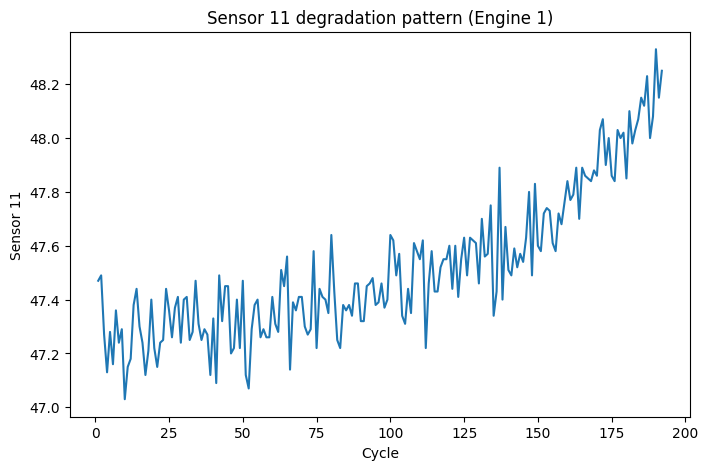

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(engine1["cycle"], engine1["sensor_11"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 degradation pattern (Engine 1)")


plt.show()

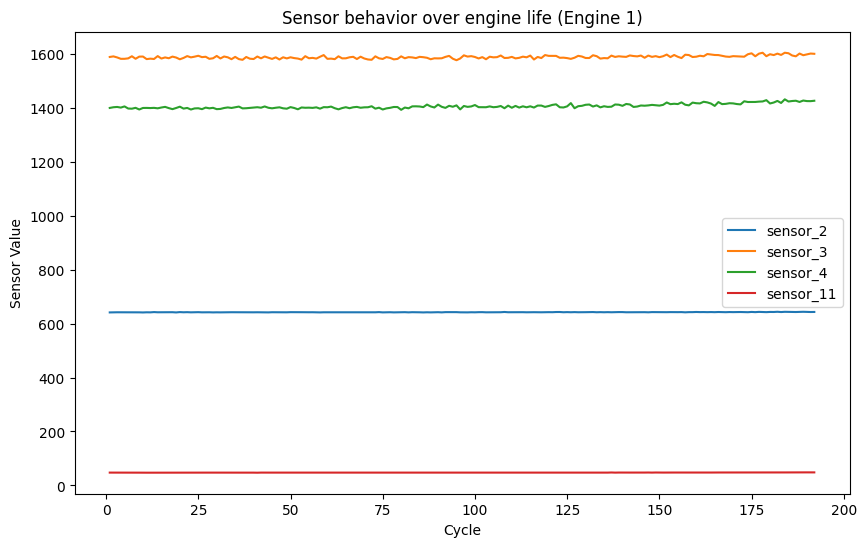

In [12]:
sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_11"]

plt.figure(figsize=(10, 6))

for sensor in sensors_to_plot:
    plt.plot(engine1["cycle"], engine1[sensor], label=sensor)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor behavior over engine life (Engine 1)")
plt.legend()

plt.show()

In [13]:

# Dropping columns with little to no variance.
drop_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
train_df = train_df.drop(columns=drop_sensors)

In [14]:
train_df.columns

Index(['engine_id', 'cycle', 'op_1', 'op_2', 'op_3', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'max_cycle', 'RUL'],
      dtype='object')

In [15]:
train_df.shape

(20631, 21)

In [16]:
y = train_df["RUL"]
X = train_df.drop(columns=["RUL", "engine_id", "max_cycle"])

In [17]:
X.shape, y.shape

((20631, 18), (20631,))

In [18]:
X.columns

Index(['cycle', 'op_1', 'op_2', 'op_3', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20',
       'sensor_21'],
      dtype='object')

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

### Machine Learning Pipeline Initialization
Constructing a Scikit-Learn `Pipeline`. It sequentially chains a `StandardScaler` to appropriately normalize the feature space, followed by a robust `RandomForestRegressor` as our predictive foundation.

In [21]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

### Model Training
Fitting our entire Random Forest scaling-and-regression pipeline securely onto the partitioned training observations.

In [22]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

### Validation Prediction
Deploying the trained pipeline onto the held-out validation segment to retrieve immediate RUL estimations.

In [24]:
y_pred = pipe.predict(X_valid)

### Validation Internal Metrics
Calculating universally standard evaluation metrics including Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to gauge early generalizability.

In [26]:
mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 25.467579355464018
RMSE: 35.98693705599518


### Extracting Feature Importances
Extracting built-in permutation weights to understand which parameters structurally contribute the strongest towards estimating failure timelines.

In [27]:
model = pipe.named_steps["model"]
importances = model.feature_importances_

### Feature Importance Tabulation
Structuring, compiling, and ordering the evaluated feature importances into a descending DataFrame chart.

In [29]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
0,cycle,0.539924
10,sensor_11,0.141871
9,sensor_9,0.042665
6,sensor_4,0.039820
11,sensor_12,0.032083
13,sensor_14,0.024583
7,sensor_7,0.023699
14,sensor_15,0.021384
17,sensor_21,0.020518
4,sensor_2,0.019116


### Visualizing Feature Importances
Generating an easy-to-read seaborn bar chart demonstrating the top 15 most instrumental sensors for modeling the RUL objective.

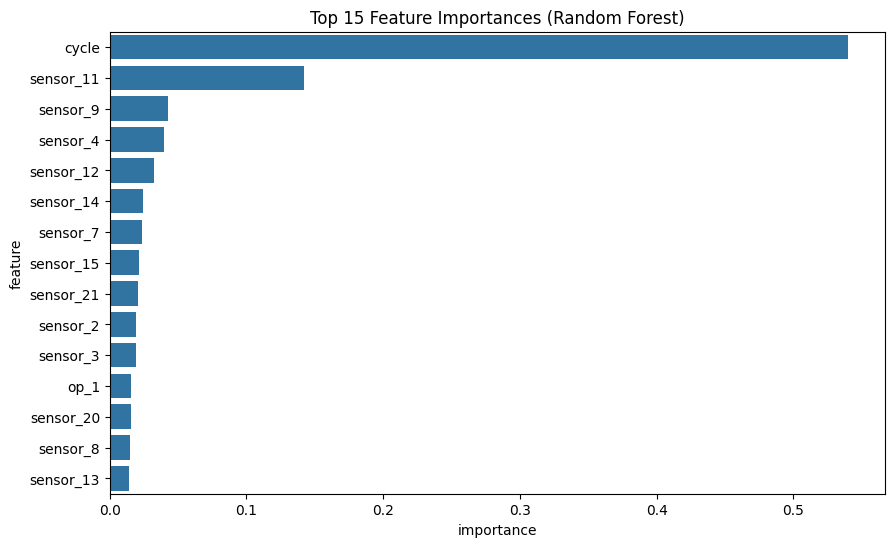

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

### Time-Series Re-sorting
Rigidly aligning and sorting the DataFrame explicitly by unique engines and strictly successive cycles. This ensures moving operations act sequentially.

In [31]:
train_df = train_df.sort_values(["engine_id", "cycle"])

### Selecting Highly Informative Sensors
Isolating a hand-picked subset of top-tier expressive sensors (derived via EDA & Random Forest Importances) to hone in on signal extraction and minimize ambient dataset noise.

In [32]:
top_sensors = ["sensor_11", "sensor_9", "sensor_4", "sensor_12", "sensor_14", "sensor_7", "sensor_15", "sensor_21", "sensor_2"]

### Rolling Statistical Mean Engineering
Synthesizing simple 5-cycle wide rolling averages continuously over the premier sensors to smooth fluctuating sensor noise and unveil fundamental linear breakdown trends.

In [33]:
for sensor in top_sensors:
    train_df[f"{sensor}_rollmean"] = (
        train_df.groupby("engine_id")[sensor]
        .rolling(window=5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

### Rolling Standard Deviation Engineering
Creating subsequent 5-cycle rolling standard deviations on paramount sensors to empirically capture rapidly shifting local variance commonly symptomatic of imminent machine stress.

In [34]:
for sensor in top_sensors:
    train_df[f"{sensor}_rollstd"] = (
        train_df.groupby("engine_id")[sensor]
        .rolling(window=5, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

### Calculating Trajectory Deltas
Extracting precise cycle-over-cycle momentum changes (deltas) iteratively within each unit allowing the model to intrinsically assess the pace of functional decay.

In [35]:
for sensor in top_sensors:
    train_df[f"{sensor}_delta"] = (
        train_df.groupby("engine_id")[sensor]
        .diff()
    )

In [36]:
train_df = train_df.fillna(0)

In [37]:
train_df.shape

(20631, 48)

In [38]:
y = train_df["RUL"]
X = train_df.drop(columns=["RUL", "engine_id", "max_cycle"])

In [40]:
X.shape

(20631, 45)

In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training
Fitting our entire Random Forest scaling-and-regression pipeline securely onto the partitioned training observations.

In [40]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

### Validation Prediction
Deploying the trained pipeline onto the held-out validation segment to retrieve immediate RUL estimations.

In [41]:
y_pred = pipe.predict(X_valid)

### Validation Internal Metrics
Calculating universally standard evaluation metrics including Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to gauge early generalizability.

In [42]:
mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 20.108638236006787
RMSE: 28.90704423026265


### Test Cohort Data Ingestion
Loading forward unseen ground-truth machine trajectories (`test_FD001.txt`) intended for purely predictive and official scoring.

In [43]:
test_df = pd.read_csv("test_FD001.txt", sep="\s+", header=None)

test_df.columns = columns
test_df.head()

,engine_id,cycle,op_1,op_2,op_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [44]:
test_df.shape

(13096, 26)

### Extracting Out-Of-Sample Test Labels
Accessing the strict `RUL_FD001.txt` repository to secure definitive final time-to-failure cycle targets accompanying each specific test turbine.

In [45]:
rul_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None
)
rul_test.columns = ["RUL"]
rul_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   RUL     100 non-null    int64
dtypes: int64(1)
memory usage: 932.0 bytes


In [46]:
test_df = test_df.drop(columns=drop_sensors)

In [47]:
test_df = test_df.sort_values(["engine_id", "cycle"])

### Rolling Statistical Mean Engineering
Synthesizing simple 5-cycle wide rolling averages continuously over the premier sensors to smooth fluctuating sensor noise and unveil fundamental linear breakdown trends.

In [48]:
for sensor in top_sensors:
    test_df[f"{sensor}_rollmean"] = (
        test_df.groupby("engine_id")[sensor]
        .rolling(window=5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

### Rolling Standard Deviation Engineering
Creating subsequent 5-cycle rolling standard deviations on paramount sensors to empirically capture rapidly shifting local variance commonly symptomatic of imminent machine stress.

In [49]:
for sensor in top_sensors:
    test_df[f"{sensor}_rollstd"] = (
        test_df.groupby("engine_id")[sensor]
        .rolling(window=5, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

### Calculating Trajectory Deltas
Extracting precise cycle-over-cycle momentum changes (deltas) iteratively within each unit allowing the model to intrinsically assess the pace of functional decay.

In [50]:
for sensor in top_sensors:
    test_df[f"{sensor}_delta"] = (
        test_df.groupby("engine_id")[sensor]
        .diff()
    )

In [51]:
test_df = test_df.fillna(0)

In [52]:
test_last = test_df.groupby("engine_id").last().reset_index()

In [53]:
test_last.shape

(100, 46)

In [54]:
X_test = test_last.drop(columns=["engine_id"])

In [68]:
X_test.shape

(100, 45)

In [55]:
y_test_pred = pipe.predict(X_test)

### Instantiating the Corrective NASA Scoring Formula
Coding the distinctive asymmetric NASA metric. It mathematically incorporates an exponential punishment for late predictions (which actively endanger flights) against far smaller penalties for relatively preemptive early approximations.

In [57]:
def nasa_score(y_true, y_pred):
    score=0
    for true, pred in zip(y_true, y_pred):
        d = pred - true
        if d < 0:
            score += np.exp(-d/13) - 1
        else:
            score += np.exp(d/10) - 1
    return score

### Test Output Production & Benchmarking
Synthesizing our predictions externally and comparing our exact outcome arrays to true values under MAE, RMSE, and significantly, the NASA specialized scoring protocol.

In [58]:
mae_test = mean_absolute_error(rul_test["RUL"], y_test_pred)
rmse_test = np.sqrt(mean_squared_error(rul_test["RUL"], y_test_pred))
score_test = nasa_score(rul_test["RUL"].values, y_test_pred)

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)
print("Test NASA Score: ", score_test)

Test MAE: 20.484
Test RMSE: 27.98552829588893
Test NASA Score:  19707.902408477283


In [59]:
errors = y_test_pred - rul_test["RUL"].values

### Evaluating Crucial Prediction Asymmetry
Examining our error distribution split to empirically measure the comparative quantity of over-cautious "early" forecasts versus dangerous "late" predictions.

In [60]:
early_predcitions = (errors < 0).sum()
late_predictions = (errors > 0).sum()

print("Early predictions: ", early_predcitions)
print("Late predictions: ", late_predictions)

Early predictions:  34
Late predictions:  66


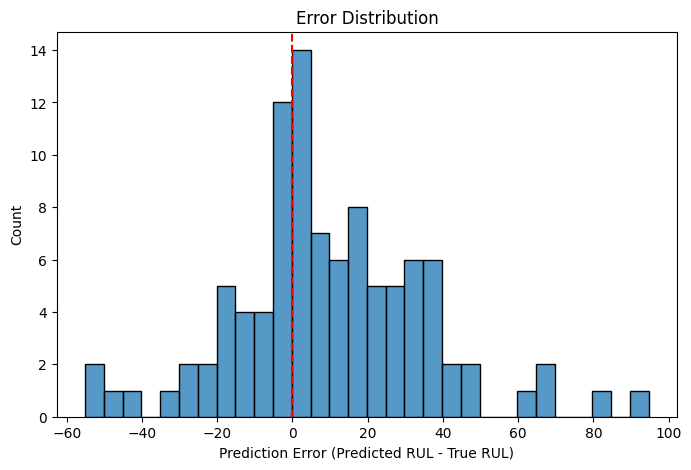

In [61]:
plt.figure(figsize=(8, 5))

sns.histplot(errors, bins=30)
plt.axvline(0, color="red", linestyle='--')

plt.xlabel("Prediction Error (Predicted RUL - True RUL)")
plt.title("Error Distribution")

plt.show()